# Model establishment and training

🔬 Universal GRU SOH Predictor
📋 Setting: 100→100, Hidden layer:128, Batch size:32
🎯 Object: Train the Dynamic GRU with MIT dataset\n
📁 Loading battery data...
  ⚠️  Bat043_SOH.xlsx: The length is not enough: pass
\n🔧 Pre processing...
📏 SoH data range: [0.7736324496, 1.0101853798]
📊 Split results:
  Train dataset: 1658 series
  Test dataset: 341 series
\n🚀 Begin training...
🚀 Begin training Dynamic GRU: cuda
Epoch   0 | Train: 0.146958 | Val: 0.017427 | LR: 0.001000
Epoch  10 | Train: 0.004550 | Val: 0.002413 | LR: 0.000993
Epoch  20 | Train: 0.002414 | Val: 0.000365 | LR: 0.000973
Epoch  30 | Train: 0.001986 | Val: 0.000363 | LR: 0.000942
Epoch  40 | Train: 0.001630 | Val: 0.000589 | LR: 0.000900
Epoch  50 | Train: 0.001544 | Val: 0.000421 | LR: 0.000848
Epoch  60 | Train: 0.001212 | Val: 0.000152 | LR: 0.000788
Epoch  70 | Train: 0.001076 | Val: 0.000714 | LR: 0.000720
Epoch  80 | Train: 0.001100 | Val: 0.000245 | LR: 0.000647
Epoch  90 | Train: 0.000804 | Val: 0.000134 | LR: 0.00057

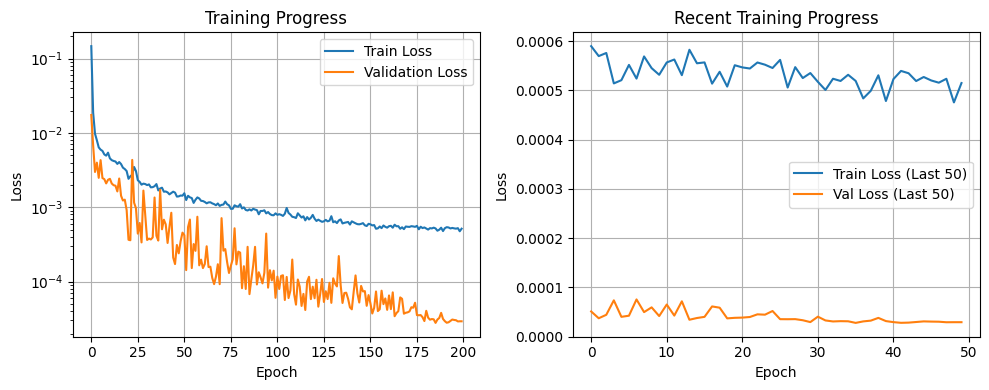

\n🧪 Test model...


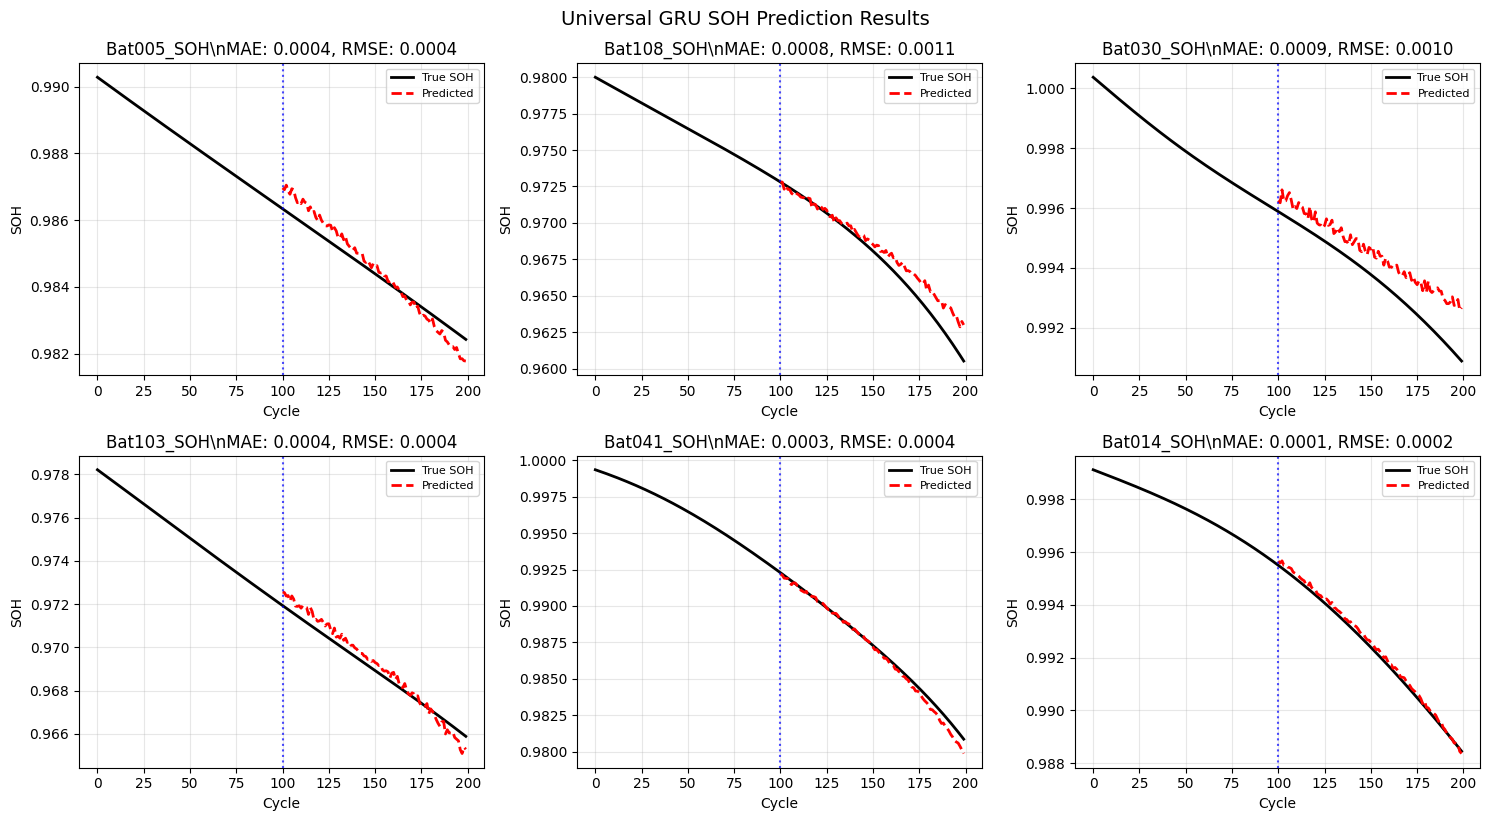

\n📊 Test results:
  Sample Number: 6
  Mean MAE: 0.000469
  Mean RMSE: 0.000656
\n✅ Train process finished! Model has been saved to universal_GRU_soh_100to100_final.pth
📊 Terminal performance: MAE=0.000469, RMSE=0.000656


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import time
import random
from sklearn.model_selection import train_test_split

# ===== Data for Dynamic Transformer =====
class UniversalSOHDataset(Dataset):
    def __init__(self, sequences, scaler):
        self.sequences = sequences
        self.scaler = scaler
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        x_seq, y_seq, battery_id = self.sequences[idx]
        x_scaled = self.scaler.transform(x_seq.reshape(-1, 1)).flatten()
        y_scaled = self.scaler.transform(y_seq.reshape(-1, 1)).flatten()
        return (torch.tensor(x_scaled, dtype=torch.float32), 
                torch.tensor(y_scaled, dtype=torch.float32),
                battery_id)

# ====================================MODELS===================================

# --------------------------------LNN-----------------------------------------
from torchdiffeq import odeint
# ===== Dynamic LNN model =====
class UniversalLNN_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100):
        super().__init__()
        
        
        self.encoder = nn.Sequential(
            nn.Linear(input_len, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh()
        )
        
        
        self.dynamics = LiquidNeuron(hidden_dim)

        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, output_len)
        )
        
        
        self.residual_weight = nn.Parameter(torch.tensor(0.1))
        
    def forward(self, x_seq):
        batch_size = x_seq.shape[0]
        device = x_seq.device
        
        x_encoded = self.encoder(x_seq)
        
        self.dynamics.u = x_seq
        
        try:    
            self.dynamics.to(device)
            
            time_steps = 10
            t = torch.linspace(0, 1, time_steps).to(device)
            
            trajectory = odeint(self.dynamics, x_encoded, t, method='euler', rtol=1e-4, atol=1e-6)
            x_dynamic = trajectory[-1]  
            
        except Exception as e:
            # If ODE failed, use fallback
            print(f"⚠️ ODE failed, use fallback: {e}")
            with torch.no_grad():
                x_dynamic = torch.tanh(self.dynamics.W(x_encoded))
        
        # Residual connection
        x_combined = x_dynamic + self.residual_weight * x_encoded
        
        # Decoding
        output = self.decoder(x_combined)
        
        return output

class LiquidNeuron(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.W = nn.Linear(dim, dim, bias=False)
        self.alpha = nn.Parameter(torch.ones(dim) * 0.5)
        self.beta = nn.Parameter(torch.ones(dim) * 0.1)
        
    def forward(self, t, x):
        device = x.device
        
        if hasattr(self, 'u') and self.u is not None:
            u_input = self.u.to(device)
            u_mean = torch.mean(u_input, dim=1, keepdim=True).expand(-1, x.shape[1])
            return -self.alpha.to(device) * x + self.beta.to(device) * torch.tanh(self.W(x) + u_mean)
        else:
            return -self.alpha.to(device) * x + self.beta.to(device) * torch.tanh(self.W(x))


# ------------------------------------Transformers------------------------------------
class UniversalTransformer_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100,
                 nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1, pool='mean'):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        self.hidden_dim = hidden_dim
        self.pool = pool

        # Input embedding: scalar → hidden_dim
        self.embedding = nn.Linear(1, hidden_dim)

        # Positional encoding (learnable)
        self.pos_encoding = nn.Parameter(torch.zeros(1, input_len, hidden_dim))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # MLP decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, output_len)
        )

    def forward(self, x):
        # x: [batch, input_len]
        x = x.unsqueeze(-1)           # → [batch, input_len, 1]
        x = self.embedding(x)         # → [batch, input_len, hidden_dim]
        x = x + self.pos_encoding     # add positional info

        # Transformer encoding
        x_encoded = self.transformer(x)  # → [batch, input_len, hidden_dim]

        # Pooling over the sequence
        if self.pool == 'mean':
            x_pooled = x_encoded.mean(dim=1)  # → [batch, hidden_dim]
        elif self.pool == 'max':
            x_pooled, _ = x_encoded.max(dim=1)
        else:
            # fallback to last token
            x_pooled = x_encoded[:, -1, :]

        # Decode to full output sequence
        out = self.decoder(x_pooled)  # → [batch, output_len]
        return out


# --------------------------------RNN-------------------------------------
class UniversalRNN_SOH(nn.Module):
    def __init__(self, input_len, hidden_dim, output_len, num_layers=2, dropout=0.1):
        super().__init__()

        # Replace LSTM with vanilla RNN
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh'    # default, but explicit
        )

        self.fc1 = nn.Linear(hidden_dim, hidden_dim)   # prunable
        self.fc2 = nn.Linear(hidden_dim, output_len)   # final output (ignore)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.unsqueeze(-1)  # (B, T, 1)

        # RNN has only h0, no c0
        h0 = torch.zeros(self.rnn.num_layers, x.size(0), self.rnn.hidden_size, device=x.device)

        out, hn = self.rnn(x, h0)
        h = hn[-1]  # last layer hidden state

        h = self.dropout(torch.relu(self.fc1(h)))
        y = self.fc2(h)
        return y


# ------------------------------------LSTM------------------------------------
class UniversalLSTM_SOH(nn.Module):
    def __init__(self, input_len, hidden_dim, output_len, num_layers=2, dropout=0.1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_dim, hidden_dim)   # prunable
        self.fc2 = nn.Linear(hidden_dim, output_len)   # final output (ignore)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.unsqueeze(-1)
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros_like(h0)

        out, (hn, _) = self.lstm(x, (h0, c0))
        h = hn[-1]

        h = self.dropout(torch.relu(self.fc1(h)))
        y = self.fc2(h)
        return y


 # ------------------------------------GRU------------------------------------
class UniversalGRU_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100, num_layers=2):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        self.hidden_dim = hidden_dim

        # GRU input size = 1 (SOH scalar per time step)
        self.encoder = nn.GRU(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.1 if num_layers > 1 else 0
        )

        # Decoder to map hidden state → output sequence
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, output_len)
        )

    def forward(self, x):
        # x: [batch, input_len]
        x = x.unsqueeze(-1)  # → [batch, input_len, 1]
        _, h_last = self.encoder(x)  # h_last: [num_layers, batch, hidden_dim]
        h_last = h_last[-1]          # Take last GRU layer → [batch, hidden_dim]
        out = self.decoder(h_last)   # → [batch, output_len]
        return out
    
# --------------------------------------CNN---------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----- Basic Residual CNN Block -----
class ResidualConv1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, stride=1, dropout=0.05):
        super().__init__()
        padding = (kernel_size - 1) // 2  # preserve sequence length

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=padding)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=stride, padding=padding)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        # Skip connection
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

# ----- Full CNN Model -----
class UniversalCNN_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100,
                 num_blocks=2, kernel_size=5, dropout=0.05, pool='mean'):
        super().__init__()
        self.pool_type = pool

        # Input embedding: scalar → hidden_dim
        self.embedding = nn.Linear(1, hidden_dim)

        # Build CNN layers
        layers = []
        for i in range(num_blocks):
            in_ch = hidden_dim if i > 0 else hidden_dim
            layers.append(
                ResidualConv1D(in_ch, hidden_dim, kernel_size=kernel_size, dropout=dropout)
            )
        self.cnn = nn.Sequential(*layers)

        # Optional attention pooling
        self.pool = nn.Linear(hidden_dim, 1) if pool == 'attention' else None

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_len)
        )

    def forward(self, x):
        # x: [B, L] → [B, L, 1]
        x = x.unsqueeze(-1)
        x = self.embedding(x)           # [B, L, hidden_dim]
        x = x.transpose(1, 2)           # [B, hidden_dim, L] for Conv1d

        x = self.cnn(x)                 # [B, hidden_dim, L]
        x = x.transpose(1, 2)           # [B, L, hidden_dim] for pooling

        # Pooling over temporal dimension
        if self.pool_type == 'mean':
            x = x.mean(dim=1)
        elif self.pool_type == 'max':
            x, _ = x.max(dim=1)
        elif self.pool_type == 'attention' and self.pool is not None:
            weights = torch.softmax(self.pool(x), dim=1)  # [B, L, 1]
            x = (x * weights).sum(dim=1)
        else:
            x = x[:, -1, :]

        out = self.decoder(x)
        return out

# --------------------------------------TCN----------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----- Chomp1d to trim padding -----
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()

# ----- Temporal Block with optional multi-scale convs -----
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.05):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        # Multi-scale convolution: kernel_size, kernel_size-2, kernel_size-4 (if >1)
        convs = []
        for k in [kernel_size, max(kernel_size-2,1), max(kernel_size-4,1)]:
            convs.append(
                nn.Conv1d(in_ch, out_ch, k, stride=1, padding=(k-1)*dilation, dilation=dilation)
            )
        self.convs = nn.ModuleList(convs)
        self.chomp = nn.ModuleList([Chomp1d((k-1)*dilation) for k in [kernel_size, max(kernel_size-2,1), max(kernel_size-4,1)]])
        self.bn = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

        # Skip connection
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = 0
        for conv, chomp in zip(self.convs, self.chomp):
            temp = conv(x)
            temp = chomp(temp)
            out += temp
        out = self.bn(out)
        out = self.relu(out)
        out = self.drop(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

# ----- Attention Pooling -----
class TemporalAttentionPool(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):  # x: [B, L, H]
        weights = torch.softmax(self.attn(x), dim=1)  # [B, L, 1]
        x_pooled = (x * weights).sum(dim=1)          # [B, H]
        return x_pooled

# ----- Full TCN -----
class UniversalTCN_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100,
                 num_levels=2, kernel_size=5, dropout=0.05, pool='attention'):
        super().__init__()
        self.pool_type = pool

        # Input embedding: scalar → hidden_dim
        self.embedding = nn.Linear(1, hidden_dim)

        # Build TCN layers with increasing dilation
        layers = []
        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = hidden_dim if i > 0 else hidden_dim
            layers.append(
                TemporalBlock(in_ch, hidden_dim, kernel_size, dilation, dropout)
            )
        self.tcn = nn.Sequential(*layers)

        # Pooling
        if pool == 'attention':
            self.pool = TemporalAttentionPool(hidden_dim)
        else:
            self.pool = None

        # Decoder MLP
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_len)
        )

    def forward(self, x):
        # x: [B, L] → [B, L, 1]
        x = x.unsqueeze(-1)
        x = self.embedding(x)           # [B, L, hidden_dim]
        x = x.transpose(1, 2)           # [B, hidden_dim, L] for Conv1d

        x = self.tcn(x)                 # [B, hidden_dim, L]
        x = x.transpose(1, 2)           # [B, L, hidden_dim] for pooling

        # Pooling over temporal dimension
        if self.pool_type == 'mean':
            x = x.mean(dim=1)
        elif self.pool_type == 'max':
            x, _ = x.max(dim=1)
        elif self.pool_type == 'attention' and self.pool is not None:
            x = self.pool(x)
        else:
            x = x[:, -1, :]

        out = self.decoder(x)
        return out

# ===== Data loading =====
def load_all_battery_data(data_dir, input_len=100, output_len=100, overlap_ratio=0.8):
    
    data_dir = Path(data_dir)
    file_paths = sorted(data_dir.glob("Bat*_SOH.xlsx"))
    
    all_sequences = []
    battery_info = {}
    
    # Calculate the step length
    step_size = max(1, int((input_len + output_len) * (1 - overlap_ratio)))
    
    # print(f" Data loading:")
    # print(f"  Input length: {input_len}, Output length: {output_len}")
    # print(f"  Overlap ratio: {overlap_ratio*100:.1f}%, Step size: {step_size}")
    # print(f"  Find {len(file_paths)} of battery files")
    
    for i, file_path in enumerate(file_paths):
        try:
            # Read data
            df = pd.read_excel(file_path)
            soh_data = df.iloc[:, 0].values
            
            # Cleaning data
            soh_data = soh_data[~np.isnan(soh_data)]  # Remove NaN
            if len(soh_data) < input_len + output_len:
                print(f"  ⚠️  {file_path.name}: The length is not enough: pass")
                continue
            
            # Data Smoothing
            if len(soh_data) > 5:
                from scipy.signal import savgol_filter
                soh_data = savgol_filter(soh_data, window_length=5, polyorder=2)
            
            battery_id = file_path.stem  
            sequence_count = 0
            
            # Generating training series
            for start_idx in range(0, len(soh_data) - input_len - output_len + 1, step_size):
                x_seq = soh_data[start_idx:start_idx + input_len]
                y_seq = soh_data[start_idx + input_len:start_idx + input_len + output_len]
                
                # Quality check
                if (x_seq.min() > 0.5 and x_seq.max() <= 1.1 and 
                    y_seq.min() > 0.5 and y_seq.max() <= 1.1):
                    all_sequences.append((x_seq, y_seq, battery_id))
                    sequence_count += 1
            
            battery_info[battery_id] = {
                'total_cycles': len(soh_data),
                'sequences': sequence_count,
                'soh_range': (soh_data.min(), soh_data.max())
            }
            
            # print(f"  ✅ {battery_id}: {len(soh_data)} cycles → {sequence_count} sequences")
            
        except Exception as e:
            print(f"  ❌ Fail to deal with {file_path.name}: {e}")
    
    # print(f"\n📈 Data summary:")
    # print(f"  Total sereis number: {len(all_sequences)}")
    # print(f"  Valid battery number: {len(battery_info)}")
    
    return all_sequences, battery_info

# ===== Train_test split =====
def smart_train_test_split(sequences, test_size=0.2, random_state=42):
    
    # Divide based on battery 
    battery_sequences = {}
    for seq in sequences:
        x, y, battery_id = seq
        if battery_id not in battery_sequences:
            battery_sequences[battery_id] = []
        battery_sequences[battery_id].append(seq)
    
    train_sequences = []
    test_sequences = []
    
    random.seed(random_state)
    
    for battery_id, battery_seqs in battery_sequences.items():
        n_test = max(1, int(len(battery_seqs) * test_size))
        test_indices = random.sample(range(len(battery_seqs)), n_test)
        
        for i, seq in enumerate(battery_seqs):
            if i in test_indices:
                test_sequences.append(seq)
            else:
                train_sequences.append(seq)
    
    print(f"📊 Split results:")
    print(f"  Train dataset: {len(train_sequences)} series")
    print(f"  Test dataset: {len(test_sequences)} series")
    
    return train_sequences, test_sequences


# ===== Training process =====

def train_universal_model(model, train_loader, val_loader, epochs=100, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    
    print(f"🚀 Begin training Dynamic {model_name}: {device}")
        
    for epoch in range(epochs):

        model.train()
        train_loss = 0.0
        
        for batch_idx, (x_batch, y_batch, _) in enumerate(train_loader):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss += loss.item()
        
        # Validation process
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_val, y_val, _ in val_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                pred_val = model(x_val)
                val_loss += criterion(pred_val, y_val).item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        scheduler.step()
        
        # Save the optimal model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_universal_{model_name}_soh.pth')
            
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.6f}")
    
    return train_losses, val_losses

# ===== Test and visualization =====
def test_universal_model(model, test_sequences, scaler, device, num_examples=5):
    
    model.eval()
    model.to(device)
    
    test_samples = random.sample(test_sequences, min(num_examples, len(test_sequences)))    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    all_errors = []
    
    for i, (x_seq, y_true, battery_id) in enumerate(test_samples):
        if i >= 6: break
        
        x_scaled = scaler.transform(x_seq.reshape(-1, 1)).flatten()
        x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            y_pred_scaled = model(x_tensor).cpu().numpy().flatten()
            y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        
        error = np.abs(y_pred - y_true)
        all_errors.extend(error)
        mae = np.mean(error)
        rmse = np.sqrt(np.mean(error**2))
        
        ax = axes[i]
        cycles = np.arange(len(x_seq) + len(y_true))
        true_full = np.concatenate([x_seq, y_true])
        pred_full = np.concatenate([x_seq, y_pred])
        
        ax.plot(cycles, true_full, 'k-', label='True SOH', linewidth=2)
        ax.plot(cycles[len(x_seq):], y_pred, 'r--', label='Predicted', linewidth=2)
        ax.axvline(len(x_seq), color='blue', linestyle=':', alpha=0.7)
        ax.set_title(f'{battery_id}\\nMAE: {mae:.4f}, RMSE: {rmse:.4f}')
        ax.set_xlabel('Cycle')
        ax.set_ylabel('SOH')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle(f'Universal {model_name} SOH Prediction Results', y=1.02, fontsize=14)
    plt.show()
    
    # 总体统计
    overall_mae = np.mean(all_errors)
    overall_rmse = np.sqrt(np.mean([e**2 for e in all_errors]))
    
    print(f"\\n📊 Test results:")
    print(f"  Sample Number: {len(test_samples)}")
    print(f"  Mean MAE: {overall_mae:.6f}")
    print(f"  Mean RMSE: {overall_rmse:.6f}")
    
    return overall_mae, overall_rmse

# ===== Main =====
if __name__ == "__main__":
    # Parameters setting
    INPUT_LEN = 100
    OUTPUT_LEN = 100
    HIDDEN_DIM = 128
    BATCH_SIZE = 32
    EPOCHS = 2
    LEARNING_RATE = 1e-3
    OVERLAP_RATIO = 0.8 
    MODELS = {"GRU"}
    for model_name in MODELS:
        # Data direction
        BASE_DIR = Path.cwd().parents[0]  # adjust the index
        data_dir = BASE_DIR / "Data_for_Main/smoothed_soh_excel"

        print(f"🔬 Universal {model_name} SOH Predictor")
        print(f"📋 Setting: {INPUT_LEN}→{OUTPUT_LEN}, Hidden layer:{HIDDEN_DIM}, Batch size:{BATCH_SIZE}")
        print(f"🎯 Object: Train the Dynamic {model_name} with MIT dataset\\n")
        
        # Load data
        print("📁 Loading battery data...")
        try:
            all_sequences, battery_info = load_all_battery_data(
                data_dir, INPUT_LEN, OUTPUT_LEN, OVERLAP_RATIO
            )
            
            if len(all_sequences) == 0:
                raise ValueError("Cannot find the series data")
                
        except Exception as e:
            print(f"❌ Failure on data loading: {e}")
            print("🔄 Generate simulated data (NOT recommended)...")
            
            # Generate simulated data
            all_sequences = []
            for i in range(20):  
                cycles = np.arange(0, 800)
                soh = 1.0 - 0.0002 * cycles - 0.0000005 * cycles**2
                soh += 0.02 * np.sin(cycles * 0.02) + 0.01 * np.random.randn(len(cycles))
                soh = np.clip(soh, 0.8, 1.0)
                
                for j in range(0, len(soh) - INPUT_LEN - OUTPUT_LEN + 1, 20):
                    x_seq = soh[j:j+INPUT_LEN]
                    y_seq = soh[j+INPUT_LEN:j+INPUT_LEN+OUTPUT_LEN]
                    all_sequences.append((x_seq, y_seq, f"SimBat{i:03d}"))
        
        # Pre-process
        print("\\n🔧 Pre processing...")
        all_soh_data = []
        for x_seq, y_seq, _ in all_sequences:
            all_soh_data.extend(x_seq)
            all_soh_data.extend(y_seq)
        
        scaler = MinMaxScaler()
        scaler.fit(np.array(all_soh_data).reshape(-1, 1))
        print(f"📏 SoH data range: [{np.min(all_soh_data):.10f}, {np.max(all_soh_data):.10f}]")
        
        # Split data
        train_sequences, test_sequences = smart_train_test_split(all_sequences, test_size=0.2)
        
        train_dataset = UniversalSOHDataset(train_sequences, scaler)
        test_dataset = UniversalSOHDataset(test_sequences, scaler)
        
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        
        # Initialization
        model_class = globals()[f"Universal{model_name}_SOH"] 
        model = model_class(100, 128, 100)  
        # model = UniversalTransformer_SOH(INPUT_LEN, HIDDEN_DIM, OUTPUT_LEN)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        # device = torch.device('cpu')
        # Training model
        print("\\n🚀 Begin training...")
        train_losses, val_losses = train_universal_model(
            model, train_loader, test_loader, 
            epochs=EPOCHS, lr=LEARNING_RATE, device=device
        )
        
        # Plot
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        plt.yscale('log')
        
        plt.subplot(1, 2, 2)
        plt.plot(train_losses[-50:], label='Train Loss (Last 50)')
        plt.plot(val_losses[-50:], label='Val Loss (Last 50)')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Recent Training Progress')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # Testing
        print("\\n🧪 Test model...")
        # Loading optimal model
        model.load_state_dict(torch.load(f'best_universal_{model_name}_soh.pth'))
        mae, rmse = test_universal_model(model, test_sequences, scaler, device, num_examples=6)
        
        # 保存最终模型
        torch.save(model.state_dict(), f'universal_{model_name}_soh_{INPUT_LEN}to{OUTPUT_LEN}_final.pth')
        torch.save(model, f'{model_name}_teacher.pth')
        print(f"\\n✅ Train process finished! Model has been saved to universal_{model_name}_soh_{INPUT_LEN}to{OUTPUT_LEN}_final.pth")
        print(f"📊 Terminal performance: MAE={mae:.6f}, RMSE={rmse:.6f}")

# Test in different SoH segments

---------------------------------gru----------------------------------
🧪 RNN SOH Segment Tester
Testing segments from different batteries and SoH ranges (100 → 100 cycles)
✅ Model loaded successfully, device: cpu
🔍 Selecting the test segments based on SoH...


[codecarbon WARNING @ 16:30:49] Multiple instances of codecarbon are allowed to run at the same time.


  HIGH: 246 segments
  MEDIUM: 246 segments
  LOW: 90 segments
✅ Final selection includes 16 test segments, covering the SoH ranges:
  HIGH: 5 segments (Average SoH: 0.973)
  MEDIUM: 7 segments (Average SoH: 0.917)
  LOW: 4 segments (Average SoH: 0.879)
📊 Created 16 test segments
✅ 1/16 - Bat018_SOH (medium, SOH:0.934, 290-490): 
MAE=0.0016, RMSE=0.0022, MAPE=0.2%, 
 Mem(MB)=493.84765625,  Inf Time: 5.0202 ms, Uncertainty (StdDev): 0.0021, Conf(95%): 99.0%
✅ 2/16 - Bat032_SOH (medium, SOH:0.906, 500-700): 
MAE=0.0163, RMSE=0.0191, MAPE=1.9%, 
 Mem(MB)=498.86328125,  Inf Time: 2.8232 ms, Uncertainty (StdDev): 0.0039, Conf(95%): 18.0%
✅ 3/16 - Bat008_SOH (low, SOH:0.889, 660-860): 
MAE=0.0215, RMSE=0.0249, MAPE=2.6%, 
 Mem(MB)=499.45703125,  Inf Time: 4.4176 ms, Uncertainty (StdDev): 0.0057, Conf(95%): 19.0%
✅ 4/16 - Bat004_SOH (high, SOH:0.951, 940-1140): 
MAE=0.0010, RMSE=0.0011, MAPE=0.1%, 
 Mem(MB)=500.4296875,  Inf Time: 5.2662 ms, Uncertainty (StdDev): 0.0030, Conf(95%): 100.0%
✅ 5

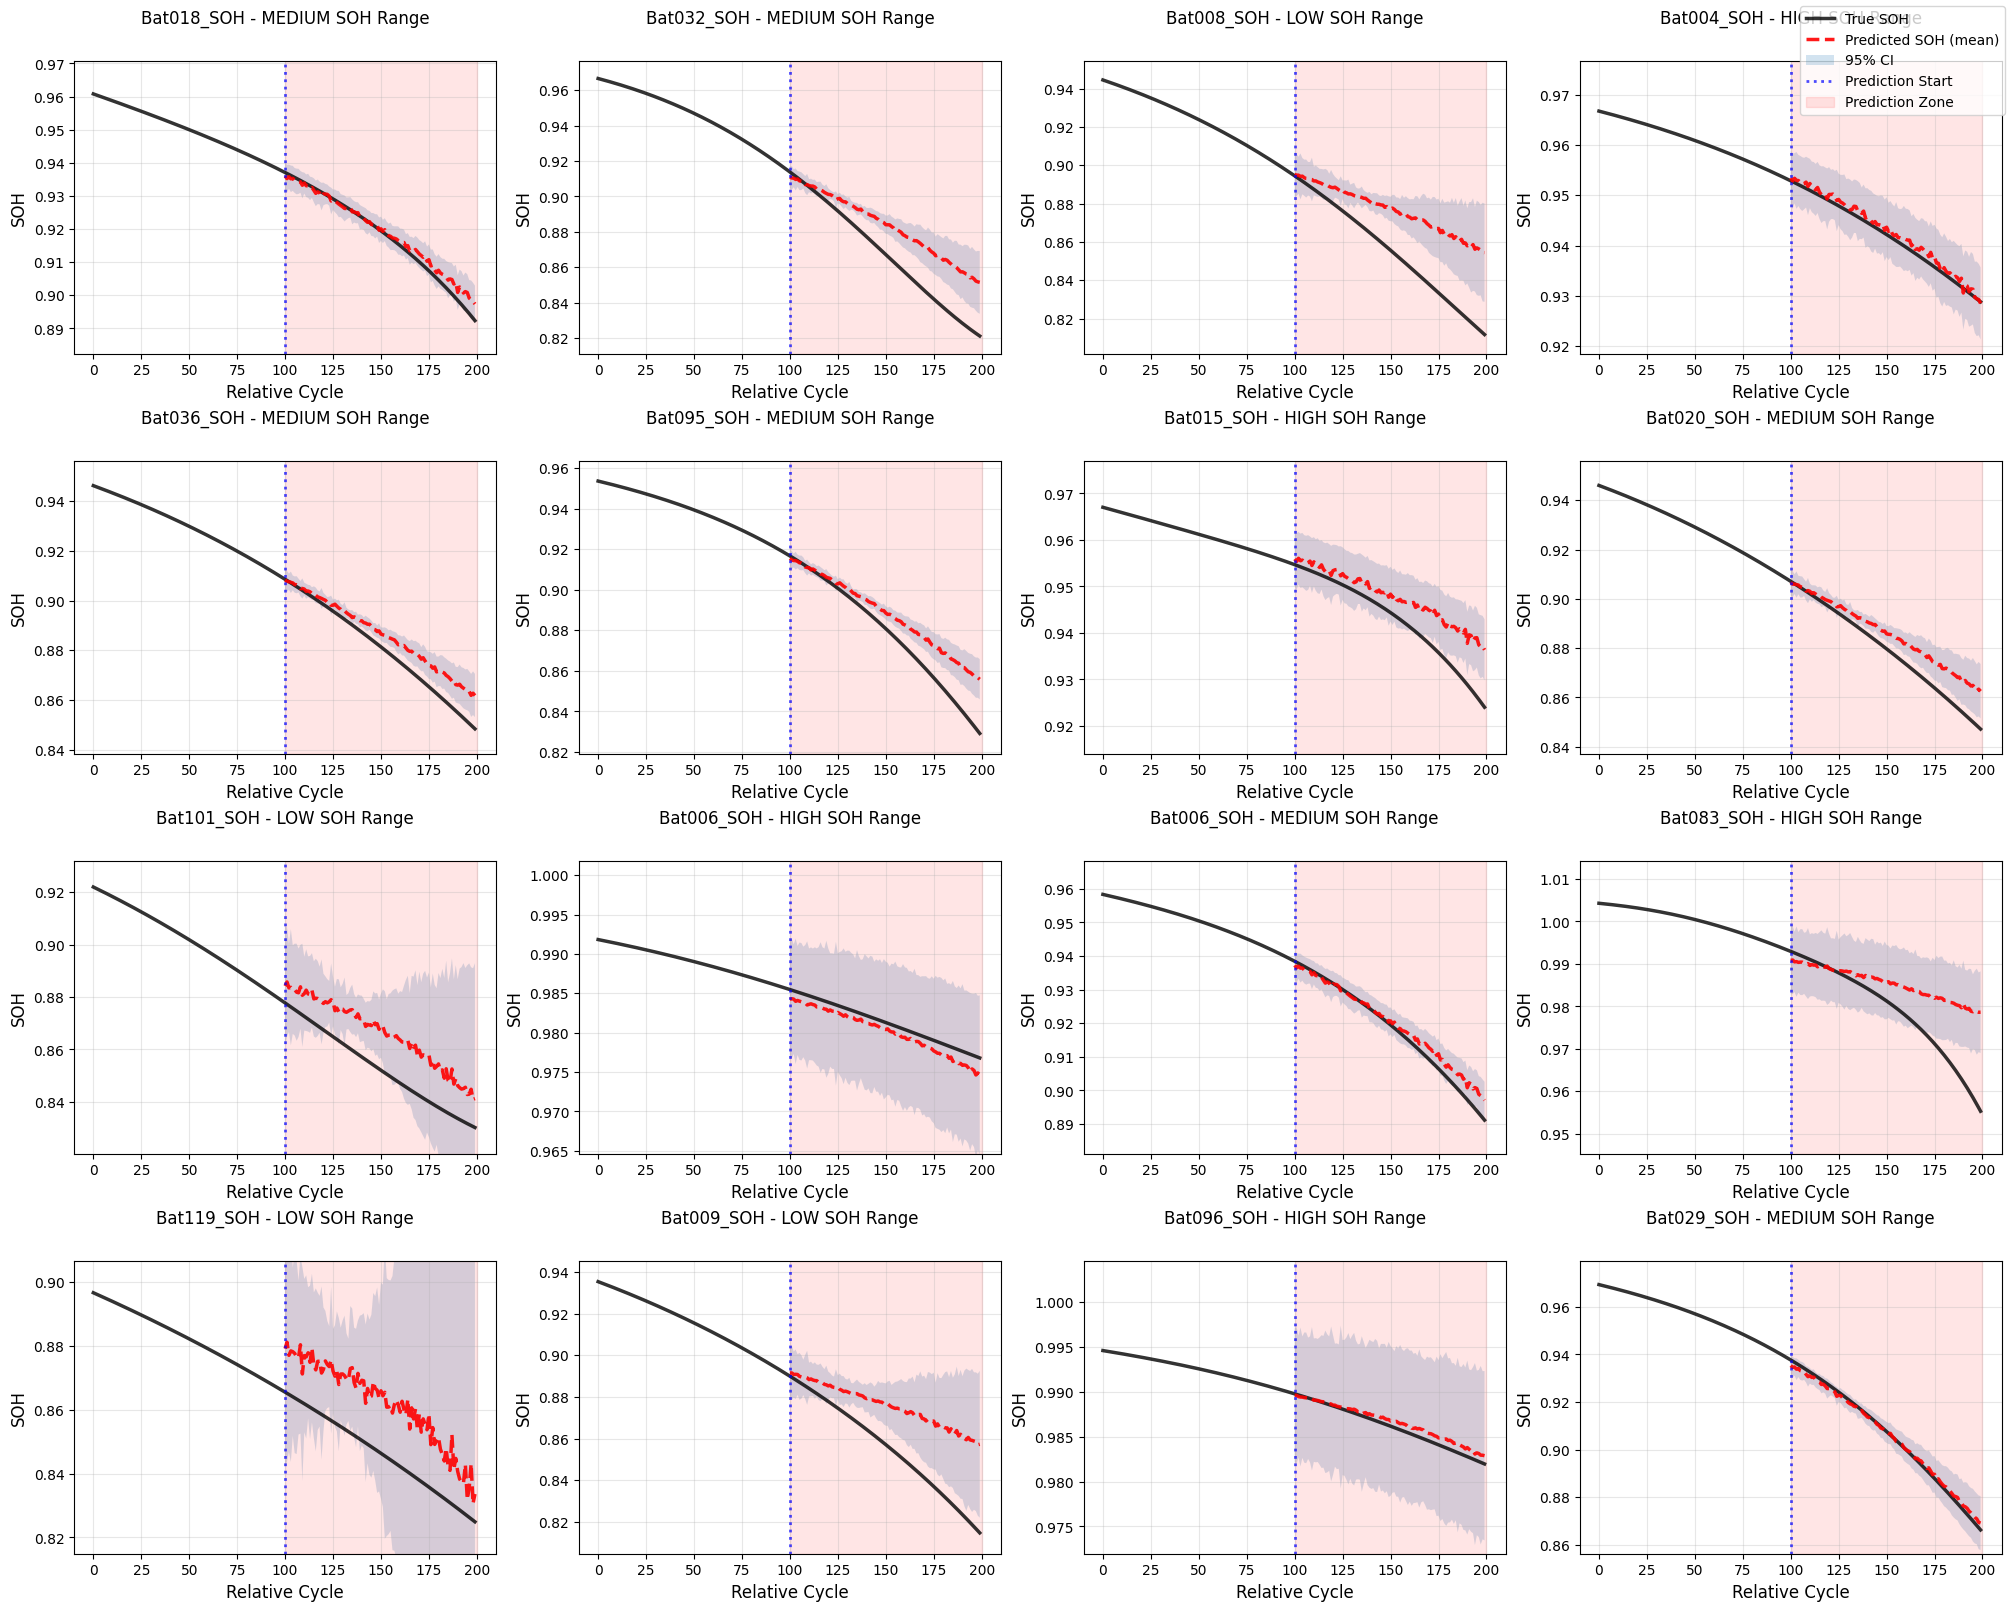

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>


📈 Test results summary (16 segments):
   Overall average: MAE=0.0081, RMSE=0.0094, MAPE=0.9%, MAE_10=0.0023, MAPE_10=0.3%, MAE_100=0.0152, MAPE_100=1.8%, Avg Inf Time=3.7338ms, Avg Uncertainty=0.0055, Avg Conf(95%)=63.31%, Mem (MB)=501.4778
   HIGH SOH interval: MAE=0.0029, RMSE=0.0037, MAPE=0.3023  MAE_10=0.0009, MAPE_10=0.0879, MAE_100=0.0078, MAPE_100=0.8251 (Average SOH:0.973, 5 segments, Avg Uncertainty=0.0038, Avg Conf: 86.40%)
   MEDIUM SOH interval: MAE=0.0062, RMSE=0.0076, MAPE=0.7217  MAE_10=0.0010, MAPE_10=0.1109, MAE_100=0.0142, MAPE_100=1.6950 (Average SOH:0.917, 7 segments, Avg Uncertainty=0.0026, Avg Conf: 54.57%)
   LOW SOH interval: MAE=0.0177, RMSE=0.0196, MAPE=2.1000  MAE_10=0.0063, MAPE_10=0.7259, MAE_100=0.0262, MAPE_100=3.2158 (Average SOH:0.879, 4 segments, Avg Uncertainty=0.0126, Avg Conf: 49.75%)
   Bast segments: Bat096_SOH (high, SOH:0.989, cycle 350) MAE=0.0006
   Worst segments: Bat008_SOH (low, SOH:0.889, cycle 660) MAE=0.0215
Saved summary to summary.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
import warnings
import random
import time                           # ADDED: necessary for timing
import os                             # ADDED: for psutil usage
warnings.filterwarnings("ignore")
from codecarbon import EmissionsTracker
import psutil
from numpy.polynomial import Polynomial



def load_model_and_scaler(model_path, data_dir):

    # device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    device = torch.device('cpu')
    model_class = globals()[f"Universal{model_name}_SOH"] 
    model = model_class(100, 128, 100)  
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    
    files = list(Path(data_dir).glob("Bat*_SOH.xlsx"))[:3]
    all_soh = []
    for f in files:
        try:
            soh = pd.read_excel(f).iloc[:, 0].values
            all_soh.extend(soh[~np.isnan(soh)][::20])  # 每20个取1个
        except: continue
    
    scaler = MinMaxScaler()
    scaler.fit(np.array(all_soh).reshape(-1, 1))
    
    return model, scaler, device

def predict_segment(model, scaler, device, input_soh, target_soh, name, mc_runs=50):
    """
    Predict using the model, perform Monte Carlo dropout for uncertainty estimation,
    compute confidence (percent of true target points falling within 95% CI),
    and measure energy/CO2/memory (using codecarbon & psutil if available).
    
    Returns:
      mean_pred (np.array): mean predicted soh (length 100)
      std_pred (np.array): predictive std (length 100)
      mae, rmse, mape, avg_inference_time,
      confidence_pct (float),
      energy_kwh (float or None),
      co2_kg (float or None),
      mem_mb (float or None)
    """
    # scale input
    input_scaled = scaler.transform(input_soh.reshape(-1, 1)).flatten()
    input_tensor = torch.tensor(input_scaled, dtype=torch.float32).unsqueeze(0).to(device)

    #---------------------Original Code (without MC uncertainty)------------------------
    # with torch.no_grad():
    #     output_scaled = model(input_tensor).cpu().numpy().flatten()
    #     predicted_soh = scaler.inverse_transform(output_scaled.reshape(-1, 1)).flatten()
    
    # # Average Error for all 100 predicted SoH
    # mae = np.mean(np.abs(predicted_soh - target_soh))
    # rmse = np.sqrt(np.mean((predicted_soh - target_soh)**2))
    # mape = np.mean(np.abs((predicted_soh - target_soh) / target_soh)) * 100

    # # Error at 10th future SoH
    # mae_10 = np.mean(np.abs(predicted_soh[9] - target_soh[9]))
    # rmse_10 = np.sqrt(np.mean((predicted_soh[9] - target_soh[9])**2))
    # mape_10 = np.mean(np.abs((predicted_soh[9] - target_soh[9]) / target_soh[9])) * 100

    # # Error at 10th future SoH
    # mae_100 = np.mean(np.abs(predicted_soh[99] - target_soh[99]))
    # rmse_100 = np.sqrt(np.mean((predicted_soh[99] - target_soh[99])**2))
    # mape_100 = np.mean(np.abs((predicted_soh[99] - target_soh[99]) / target_soh[99])) * 100

    #-----------------------------------------------------------------------------------

    # --- Monte Carlo dropout runs ---
    mc_outputs = []
    # Setup emissions tracker if available
    tracker = EmissionsTracker(measure_power_secs=1, log_level="error",output_dir = "results_gru", output_file=f"emissions_{name}.csv", allow_multiple_runs = True)
       
    # record memory before/after (best-effort)
    mem_before = None
    mem_after = None
    proc = psutil.Process(os.getpid())
    mem_before = proc.memory_info().rss / 1024**2  # MB

    # Enable dropout during MC sampling by setting model.train()
    model.train()
    # But avoid grad computation
    with torch.no_grad():
        for _ in range(mc_runs):
            out_scaled = model(input_tensor).cpu().numpy().flatten()
            out_inv = scaler.inverse_transform(out_scaled.reshape(-1, 1)).flatten()
            mc_outputs.append(out_inv)


   # Restore eval mode
    model.eval()
    # memory after
    proc = psutil.Process(os.getpid())
    mem_after = proc.memory_info().rss / 1024**2  # MB

    # convert mc outputs
    mc_array = np.stack(mc_outputs, axis=0)  # (mc_runs, output_len)
    predicted_mean = np.mean(mc_array, axis=0)
    predicted_std = np.std(mc_array, axis=0)
    unc = np.mean(predicted_std)

    # # compute point-wise metrics between mean prediction and target
    mae = np.mean(np.abs(predicted_mean - target_soh))
    rmse = np.sqrt(np.mean((predicted_mean - target_soh)**2))
    mape = np.mean(np.abs((predicted_mean - target_soh) / target_soh)) * 100

    # Error at 10th future SoH
    mae_10 = np.mean(np.abs(predicted_mean[9] - target_soh[9]))
    mape_10 = np.mean(np.abs((predicted_mean[9] - target_soh[9]) / target_soh[9])) * 100

    # Error at 10th future SoH
    mae_100 = np.mean(np.abs(predicted_mean[99] - target_soh[99]))
    mape_100 = np.mean(np.abs((predicted_mean[99] - target_soh[99]) / target_soh[99])) * 100

    #=======================================================================
    # timing: keep the same logic, but guard cuda call if not available
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    # Warm-up (important for CPU/GPU to stabilize caches)
    for _ in range(10):
        _ = model(input_tensor)
    # Timing
    tracker.start()
    start_time = time.perf_counter()
    with torch.no_grad():
        sam_scaled = model(input_tensor).cpu().numpy().flatten()
        sam_inv = scaler.inverse_transform(sam_scaled.reshape(-1, 1)).flatten()
    end_time = time.perf_counter()
    tracker.stop()
    inf_time = ((end_time - start_time) * 1000) # in ms
    #=======================================================================

    # Confidence: percent of true target points within 95% predictive interval
    ci_low = predicted_mean - 1.96 * predicted_std
    ci_high = predicted_mean + 1.96 * predicted_std
    within = np.logical_and(target_soh >= ci_low, target_soh <= ci_high)
    confidence_pct = 100.0 * np.sum(within) / len(target_soh)

    # Memory footprint: report end memory if available, else None
    mem_mb = None
    if (mem_before is not None) and (mem_after is not None):
        mem_mb = mem_after  # current RSS in MB
    elif mem_after is not None:
        mem_mb = mem_after

    return predicted_mean, predicted_std, unc, mae, rmse, mape, inf_time, confidence_pct, mem_mb, mae_10, mape_10, mae_100, mape_100

def create_test_segments(data_dir, num_segments=12):

    files = list(Path(data_dir).glob("Bat*_SOH.xlsx"))
    all_segments = []
    
    # 定义SOH区间
    soh_ranges = [
        (0.95, 1.0, "high"),      # High SoH segments
        (0.90, 0.95, "medium"),   # Medium SoH segments  
        (0.85, 0.90, "low"),      # Low SoH segments
        (0.80, 0.85, "very_low")  # Edge SoH segments
    ]
    
    print("🔍 Selecting the test segments based on SoH...")
    
    for file_path in files:
        try:
            soh_data = pd.read_excel(file_path).iloc[:, 0].values
            soh_data = soh_data[~np.isnan(soh_data)]
            
            if len(soh_data) < 250: continue
            
            battery_name = file_path.stem
            
            # Searching the optimal SoH segment
            for min_soh, max_soh, range_name in soh_ranges:
                # Searching the beginning points of SoH
                valid_starts = []
                
                for i in range(0, len(soh_data) - 200, 10):  # Check every 10 cycles
                    segment_soh = soh_data[i:i+200]
                    if len(segment_soh) == 200:
                        avg_soh = np.mean(segment_soh)
                        if min_soh <= avg_soh <= max_soh:
                            valid_starts.append({
                                'start': i,
                                'avg_soh': avg_soh,
                                'min_soh': np.min(segment_soh),
                                'max_soh': np.max(segment_soh)
                            })
                
                # If suitable segments are found, randomly select 1–2 of them
                if valid_starts:
                    # Sort by average SoH to select representative segments
                    valid_starts.sort(key=lambda x: x['avg_soh'])
                    
                    # Select representative segments from the interval
                    if len(valid_starts) >= 3:
                        # Select segments from the beginning, middle, and end
                        selected = [valid_starts[0], 
                                  valid_starts[len(valid_starts)//2], 
                                  valid_starts[-1]]
                    else:
                        selected = valid_starts
                    
                    for seg in selected[:2]:  # Select at most 2 segments
                        all_segments.append({
                            'battery': battery_name,
                            'start': seg['start'],
                            'end': seg['start'] + 200,
                            'soh_range': range_name,
                            'avg_soh': seg['avg_soh'],
                            'min_soh': seg['min_soh'],
                            'max_soh': seg['max_soh']
                        })
                        
        except Exception as e:
            continue
    
    # Dividing based on SOH
    segments_by_range = {}
    for seg in all_segments:
        range_name = seg['soh_range']
        if range_name not in segments_by_range:
            segments_by_range[range_name] = []
        segments_by_range[range_name].append(seg)
    
    # Print the number of valid segments
    for range_name, segments in segments_by_range.items():
        print(f"  {range_name.upper()}: {len(segments)} segments")
    
    # Stratified sampling: ensure each SoH range has representatives
    final_segments = []
    target_per_range = max(2, num_segments // len(soh_ranges))
    
    for range_name, segments in segments_by_range.items():
        if segments:
            # Randomly select from each SoH range
            num_select = min(target_per_range, len(segments))
            selected = random.sample(segments, num_select)
            final_segments.extend(selected)
    
    # If the total number is insufficient, randomly supplement
    remaining = num_segments - len(final_segments)
    if remaining > 0 and all_segments:
        remaining_pool = [s for s in all_segments if s not in final_segments]
        if remaining_pool:
            additional = random.sample(remaining_pool, min(remaining, len(remaining_pool)))
            final_segments.extend(additional)
    
    # Shuffle the final selection
    random.shuffle(final_segments)
    
    print(f"✅ Final selection includes {len(final_segments)} test segments, covering the SoH ranges:")
    for range_name in ["high", "medium", "low", "very_low"]:
        count = len([s for s in final_segments if s['soh_range'] == range_name])
        if count > 0:
            avg_soh = np.mean([s['avg_soh'] for s in final_segments if s['soh_range'] == range_name])
            print(f"  {range_name.upper()}: {count} segments (Average SoH: {avg_soh:.3f})")
    
    return final_segments[:num_segments]

def test_segments(model_path, data_dir, name, num_segments=12):
    """Test multiple battery segments"""
    # Load model
    try: 
        model, scaler, device = load_model_and_scaler(model_path, data_dir)
        torch.save(model, f'{model_name}_teacher.pth')
    except:
        model=torch.load(model_path, map_location="cpu", weights_only = False)

    files = list(Path(data_dir).glob("Bat*_SOH.xlsx"))[:3]
    all_soh = []
    for f in files:
        try:
            soh = pd.read_excel(f).iloc[:, 0].values
            all_soh.extend(soh[~np.isnan(soh)][::20])  # 每20个取1个
        except: continue
    
    scaler = MinMaxScaler()
    scaler.fit(np.array(all_soh).reshape(-1, 1))
    #==================================================================

    # If load_model_and_scaler was used previously, device would exist; ensure we set device:
    device = torch.device('cpu')

    print(f"✅ Model loaded successfully, device: {device}")

    # Create test segments
    test_segments = create_test_segments(data_dir, num_segments)
    print(f"📊 Created {len(test_segments)} test segments")

    results = []
    n_segments = len(test_segments)  # should be 16
    cols = 4
    rows = int(np.ceil(n_segments / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4), constrained_layout=True)
    axes = axes.flatten()
    axes = axes.flatten() 
            
    for i, segment in enumerate(test_segments):
        try:
            # Read battery data
            file_path = Path(data_dir) / f"{segment['battery']}.xlsx"
            soh_data = pd.read_excel(file_path).iloc[:, 0].values
            soh_data = soh_data[~np.isnan(soh_data)]

            # Extract test segment
            start_idx = segment['start']
            end_idx = min(segment['end'], len(soh_data))

            if end_idx - start_idx < 200:
                continue

            # Define input and target
            input_soh = soh_data[start_idx:start_idx + 100]
            target_soh = soh_data[start_idx + 100:start_idx + 200]

            # Predict with MC dropout and resource tracking
            (pred_mean, pred_std, unc, mae, rmse, mape, inf_time,
             confidence_pct, mem_mb, mae_10, mape_10, mae_100, mape_100) = predict_segment(
                 model, scaler, device, input_soh, target_soh, name, mc_runs=100
             )

            results.append({
                'battery': segment['battery'],
                'start_cycle': start_idx,
                'soh_range': segment['soh_range'],
                'avg_soh': segment['avg_soh'],
                'mae': mae,
                'rmse': rmse,
                'mape': mape,
                'uncertainty': unc,
                'confidence_pct': confidence_pct,
                'inf_time': inf_time,
                'mem_mb': mem_mb,
                'mae_10': mae_10,
                'mape_10': mape_10,
                'mae_100': mae_100,
                'mape_100': mape_100

            })
            
            # Plot each test segment individually (with uncertainty band)
            plt.figure(figsize=(10, 6))
            ax = axes[i]
            cycles = np.arange(200)
            true_full = np.concatenate([input_soh, target_soh])
            pred_full = np.concatenate([input_soh, pred_mean])  # show mean for full

            ax.plot(cycles, true_full, 'k-', label='True SOH', linewidth=2.5, alpha=0.8)
            ax.plot(cycles[100:], pred_mean, 'r--', label='Predicted SOH (mean)', linewidth=2.5, alpha=0.9)

            # 95% CI shading
            ci_low = pred_mean - 1.96 * pred_std
            ci_high = pred_mean + 1.96 * pred_std
            ax.fill_between(cycles[100:], ci_low, ci_high, alpha=0.2, label='95% CI')

            ax.axvline(100, color='blue', linestyle=':', alpha=0.7, linewidth=2, label='Prediction Start')

            # Highlight prediction region
            ax.axvspan(100, 200, alpha=0.1, color='red', label='Prediction Zone')

            # title_extra = (f'Cycles {start_idx}-{start_idx+200} (Avg SOH: {segment["avg_soh"]:.3f})\n'
            #                f'MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.1f}% | Conf(95%): {confidence_pct:.1f}%\n'
            #                f'Inf Time: {inf_time:.4f} ms | Mem: {mem_mb:.1f} MB')

            ax.set_title(f'{segment["battery"]} - {segment["soh_range"].upper()} SOH Range\n',
                      fontsize=12, pad=12)

            ax.set_xlabel('Relative Cycle', fontsize=12)
            ax.set_ylabel('SOH', fontsize=12)
            # plt.legend(fontsize=11, loc='upper right')
            ax.grid(True, alpha=0.3)
            
            # Set the Y range
            y_min = min(np.min(true_full), np.min(pred_full)) - 0.01
            y_max = max(np.max(true_full), np.max(pred_full)) + 0.01
            ax.set_ylim(y_min, y_max)
            
            print(f"✅ {i+1}/{len(test_segments)} - {segment['battery']} ({segment['soh_range']}, SOH:{segment['avg_soh']:.3f}, {start_idx}-{start_idx+200}): \n"
                  f"MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.1f}%, \n"
                  f" Mem(MB)={mem_mb},  Inf Time: {inf_time:.4f} ms, Uncertainty (StdDev): {unc:.4f}, Conf(95%): {confidence_pct:.1f}%")
            
        except Exception as e:
            print(f"❌ {segment['battery']}: {e}")
            continue
    # # Remove any unused axes if segments < rows*cols
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    # Show once at the end
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout()
    # plt.savefig(f"stu_hd{STU_DIM}_a{ALPHA}_E{EPOCH}.png")
    plt.close()
    plt.show()
        
    
    # Print the statistical results
    if results:
        print(f"\n📈 Test results summary ({len(results)} segments):")
        summary_data = []
        main_summary = []
        
        # 总体统计 (overall stats)
        avg_mae = np.mean([r['mae'] for r in results])
        avg_rmse = np.mean([r['rmse'] for r in results])
        avg_mape = np.mean([r['mape'] for r in results])
        avg_inf = np.mean([r['inf_time'] for r in results])
        avg_conf = np.mean([r['confidence_pct'] for r in results])
        avg_mem = np.mean([r['mem_mb'] for r in results])
        avg_unc = np.mean([r['uncertainty'] for r in results])

        # new: 10 & 100 averages
        avg_mae_10 = np.mean([r['mae_10'] for r in results])
        avg_mape_10 = np.mean([r['mape_10'] for r in results])

        avg_mae_100 = np.mean([r['mae_100'] for r in results])
        avg_mape_100 = np.mean([r['mape_100'] for r in results])

        print(f"   Overall average: MAE={avg_mae:.4f}, RMSE={avg_rmse:.4f}, MAPE={avg_mape:.1f}%, "
            f"MAE_10={avg_mae_10:.4f}, MAPE_10={avg_mape_10:.1f}%, "
            f"MAE_100={avg_mae_100:.4f}, MAPE_100={avg_mape_100:.1f}%, "
            f"Avg Inf Time={avg_inf:.4f}ms, Avg Uncertainty={avg_unc:.4f}, Avg Conf(95%)={avg_conf:.2f}%, Mem (MB)={avg_mem:.4f}")
                
        # Read CSV file
        df_e = pd.read_csv(rf"C:\Users\Desktop\Final_Project\Final_Project\EntroLNN_code\Model train and Figure\results_gru\emissions_dd_{name}.csv")

        summary_data.append({
            'Segment': 'Overall',
            # 'Sparsity': n,
            # 'Pruning Type': p,
            'Hidden_dim': STU_DIM,
            'Alpha': ALPHA,
            'Epochs': EPOCH,
            'MAE': avg_mae,
            'RMSE': avg_rmse,
            'MAPE (%)': avg_mape,
            'MAE_10': avg_mae_10,
            'MAPE_10 (%)': avg_mape_10,
            'MAE_100': avg_mae_100,
            'MAPE_100 (%)': avg_mape_100,
            'Avg Uncertainty' : avg_unc,
            'Avg Conf (%)': avg_conf,
            'Avg Inf Time (ms)': avg_inf,
            'Mem (MB)': avg_mem,
            'Model Size (kB)': os.path.getsize(model_path) / 1024,
            'Energy': df_e["energy_consumed"].mean(),
            'Emission': df_e["emissions"].mean(),
            'Count': len(results)
        })

        main_summary.extend(summary_data)
        file_path = f"results_gru/summary_dd.csv"

        # Create DataFrame
        df = pd.DataFrame(main_summary)
        # Append if file exists, otherwise write with header
        if os.path.exists(file_path):
            df.to_csv(file_path, mode="a", header=False, index=False)
        else:
            df.to_csv(file_path, index=False)
        
        # Based on SoH segments
        soh_ranges = ['high', 'medium', 'low', 'very_low']
        for soh_range in soh_ranges:
            range_results = [r for r in results if r['soh_range'] == soh_range]
            if range_results:
                range_mae = np.mean([r['mae'] for r in range_results])
                range_rmse = np.mean([r['rmse'] for r in range_results])
                range_mape = np.mean([r['mape'] for r in range_results])
                range_mae_10 = np.mean([r['mae_10'] for r in range_results])
                range_mape_10 = np.mean([r['mape_10'] for r in range_results])
                range_mae_100 = np.mean([r['mae_100'] for r in range_results])
                range_mape_100 = np.mean([r['mape_100'] for r in range_results])
                avg_soh = np.mean([r['avg_soh'] for r in range_results])
                avg_conf_range = np.mean([r['confidence_pct'] for r in range_results])
                avg_unc_range = np.mean([r['uncertainty'] for r in range_results])

                print(f"   {soh_range.upper()} SOH interval: "
                    f"MAE={range_mae:.4f}, RMSE={range_rmse:.4f}, MAPE={range_mape:.4f}  "
                    f"MAE_10={range_mae_10:.4f}, MAPE_10={range_mape_10:.4f}, "
                    f"MAE_100={range_mae_100:.4f}, MAPE_100={range_mape_100:.4f} "
                    f"(Average SOH:{avg_soh:.3f}, {len(range_results)} segments, Avg Uncertainty={avg_unc_range:.4f}, Avg Conf: {avg_conf_range:.2f}%)")

                summary_data.append({
                    'Segment': f"{soh_range.upper()} SOH",
                    'MAE': range_mae,
                    'RMSE': range_rmse,
                    'MAPE (%)': range_mape,
                    'MAE_10': range_mae_10,
                    'MAPE_10 (%)': range_mape_10,
                    'MAE_100': range_mae_100,
                    'MAPE_100 (%)': range_mape_100,
                    'Avg Inf Time (ms)': np.nan,
                    'Avg Uncertainty' : avg_unc_range,
                    'Avg Conf (%)': avg_conf_range,
                    'Mem (MB)': np.nan,
                    'Count': len(range_results),
                    'Average SOH': avg_soh
                })
 
        # Best and worst
        best = min(results, key=lambda x: x['mae'])
        worst = max(results, key=lambda x: x['mae'])
        print(f"   Bast segments: {best['battery']} ({best['soh_range']}, SOH:{best['avg_soh']:.3f}, cycle {best['start_cycle']}) MAE={best['mae']:.4f}")
        print(f"   Worst segments: {worst['battery']} ({worst['soh_range']}, SOH:{worst['avg_soh']:.3f}, cycle {worst['start_cycle']}) MAE={worst['mae']:.4f}")

        summary_data.append({
            'Segment': 'Best Segment',
            'Battery': best['battery'],
            'SOH Range': best['soh_range'],
            'SOH': best['avg_soh'],
            'Cycle': best['start_cycle'],
            'MAE': best['mae']
        })
        summary_data.append({
            'Segment': 'Worst Segment',
            'Battery': worst['battery'],
            'SOH Range': worst['soh_range'],
            'SOH': worst['avg_soh'],
            'Cycle': worst['start_cycle'],
            'MAE': worst['mae']
        })


        # Save to CSV
        df = pd.DataFrame(summary_data)
        df.to_csv(f"results_gru/summary_{name}.csv", index=False)
        print("Saved summary to summary.csv")

    return results

# Main
if __name__ == "__main__":
    INPUT_LEN = 100
    OUTPUT_LEN = 100
    HIDDEN_DIM = 128
    BATCH_SIZE = 32
    # EPOCHS = 200
    LEARNING_RATE = 1e-3
    OVERLAP_RATIO = 0.8
    # STU_HIDDEN_DIM = {"ptq"}
    # ALPHA_VAL = {"ori", "s5", "gs3"}
    model_name = "RNN"
    STU_HIDDEN_DIM= {"_"}
    ALPHA_VAL = {" "}
    EPOCH = 200
    BASE_DIR = Path.cwd().parents[0]  
    DATA_DIR = BASE_DIR / "Data_for_Main/smoothed_soh_excel"

    for STU_DIM in STU_HIDDEN_DIM:
        for ALPHA in ALPHA_VAL:
            try:
                MODEL_PATH = BASE_DIR / f"Model Train and Figure/best_universal_{model_name}_soh.pth"
                random.seed(42)
                # name = f"{STU_DIM}_{ALPHA}"
                name = "gru"
                print(f"---------------------------------{name}----------------------------------")
                print(f"🧪 {model_name} SOH Segment Tester")
                print("Testing segments from different batteries and SoH ranges (100 → 100 cycles)")

                results = test_segments(MODEL_PATH, DATA_DIR, name, num_segments=16)  # Increase number of test segments to cover more SoH ranges
                print("\n✅ Segment testing completed!")
                            
            except Exception as e:
                print(f"\n❌ Failed: {e}")


    # num = {'1', '2', '3', '5', '7', '9'}
    # pr = {"struct", "global_struct"}
    # epochs = 200
    # for n in num:
    #     for p in pr: 
    #         try:       
    #             MODEL_PATH = BASE_DIR / f"Model Compression All/saved_full_models{n}\retrained_pruned_models\retrained_tp_{p}.pth"
    #             random.seed(42)
     #            name = f"{STU_DIM}_{ALPHA}"
    #             name = f"rep_tp_{p}{n}"
    #             print(f"---------------------------------{name}----------------------------------")
    #             # print("🧪 LNN SOH Segment Tester")
    #             # print("Testing segments from different batteries and SoH ranges (100 → 100 cycles)")

    #             results = test_segments(MODEL_PATH, DATA_DIR, name, num_segments=16)  # Increase number of test segments to cover more SoH ranges
    #             # print("\n✅ Segment testing completed!")
                            
    #         except Exception as e:
    #             print(f"\n❌ Failed: {e}")

    # C:\Users\AppData\Local\Temp\.codecarbon.lock - to clear CodeCarbon Cache
